# Project 1 — Tabular Q-Learning on `Taxi-v3`
### RL in Production Workshop · Assignment

**Goal:** Implement the Q-learning algorithm *from scratch* (no neural networks) and
train an agent to solve the classic **Taxi** dispatch problem. By the end you will
have a working agent, learning curves, and a set of small experiments that build
real intuition for the Bellman update.

> This is the foundation for Project 2. DQN is "Q-learning where the table is
> replaced by a neural network" — so make sure every line here makes sense before
> you move on.

---
### What you'll do
1. Explore the Taxi MDP (states, actions, rewards).
2. Implement the **Q-table**, the **epsilon-greedy** policy, and the **Bellman update**.
3. Train the agent and plot its learning curve.
4. Watch the trained taxi solve episodes.
5. Run **ablation experiments** and explain what you observe.

### How this notebook works
- Cells marked **`# ✅ PROVIDED`** are done for you — read them, run them.
- Cells marked **`# 📝 TODO`** are where *you* write code. Look for `raise NotImplementedError`
  and the `# YOUR CODE HERE` comments.
- Markdown cells with **✍️ Your answer:** expect a short written response (2–4 sentences).

**Runtime:** CPU is fine. No GPU needed. Total training takes < 1 minute.


## 1. Setup

`Taxi-v3` ships with Gymnasium. We only need `gymnasium`, `numpy`, and `matplotlib`.

In [1]:
# ✅ PROVIDED — install & import
!pip install -q "gymnasium[toy-text]==0.29.1"

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import deque
import random

# Reproducibility
SEED = 0
np.random.seed(SEED)
random.seed(SEED)
print("gymnasium:", gym.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.1 which is incompatible.
gymnasium: 0.29.1


## 2. Meet the environment: the Taxi MDP

In `Taxi-v3` a taxi moves on a 5×5 grid. There are 4 marked locations (R, G, Y, B).
An episode: a passenger starts at one location and wants to go to another. The taxi
must **drive to the passenger, pick them up, drive to the destination, and drop off**.

- **States:** 500 discrete states — encoding `(taxi_row, taxi_col, passenger_location, destination)`.
- **Actions (6):** `0=South, 1=North, 2=East, 3=West, 4=Pickup, 5=Dropoff`.
- **Rewards:** `-1` per step (encourages speed), `+20` for a correct dropoff,
  `-10` for an illegal pickup/dropoff.

This is a tiny but genuine **dispatch / logistics** problem — exactly the kind of
sequential decision task RL is deployed on in production.

Run the cell below to inspect the spaces and render one random state.

In [2]:
# ✅ PROVIDED — inspect the environment
env = gym.make("Taxi-v3", render_mode="ansi")

n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"Number of states : {n_states}")
print(f"Number of actions: {n_actions}")

state, info = env.reset(seed=SEED)
print(f"\nStarting state index: {state}")
print(env.render())

Number of states : 500
Number of actions: 6

Starting state index: 314
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




## 3. The Q-table  📝 TODO

The **Q-table** `Q[s, a]` stores our current estimate of the *expected return* of
taking action `a` in state `s` and behaving greedily afterwards.

Its shape is `(n_states, n_actions)` = `(500, 6)`. We initialize it to **zeros**
(an optimistic-enough, neutral start).

In [4]:
import numpy as np

# 📝 TODO — create the Q-table
# Create a NumPy array of zeros with shape (n_states, n_actions), dtype float.

# YOUR CODE HERE
Q = np.zeros((n_states, n_actions), dtype=float)

assert Q.shape == (n_states, n_actions)
print("Q-table shape:", Q.shape)

Q-table shape: (500, 6)


## 4. Epsilon-greedy action selection  📝 TODO

We must balance **exploration** (try new actions) and **exploitation** (use the best
known action). The epsilon-greedy rule:

- With probability **ε**, pick a **random** action.
- Otherwise (prob **1 − ε**), pick the action with the **highest Q-value** in this state:
  `argmax_a Q[s, a]`.


In [6]:
# 📝 TODO — epsilon-greedy policy
def epsilon_greedy(Q, state, epsilon):
    """Return an action index using the epsilon-greedy rule."""
    # YOUR CODE HERE
    # Hint: use np.random.random() for the coin flip,
    #       env.action_space.sample() (or np.random.randint) for a random action,
    #       np.argmax(Q[state]) for the greedy action.
    if np.random.random() < epsilon:
        return env.action_space.sample() # Explore: take a random action
    else:
        return np.argmax(Q[state]) # Exploit: take the greedy action


# quick sanity check: with epsilon=0 it must return the greedy action
Q_test = np.zeros((n_states, n_actions))
Q_test[0, 3] = 1.0
assert epsilon_greedy(Q_test, 0, epsilon=0.0) == 3
print("epsilon_greedy looks good ✅")

epsilon_greedy looks good ✅


## 5. The Q-learning update — the heart of everything  📝 TODO

After taking action `a` in state `s`, observing reward `r` and next state `s'`, we
update our estimate toward the **TD target**:

$$
Q(s,a) \;\leftarrow\; Q(s,a) \;+\; \alpha \Big[\, \underbrace{r + \gamma \max_{a'} Q(s', a')}_{\text{TD target}} \;-\; Q(s,a) \,\Big]
$$

- **α (alpha)** — learning rate: how much we move toward the target.
- **γ (gamma)** — discount: how much we value future reward.
- The bracket is the **TD error**.

Because Q-learning bootstraps off `max_a' Q(s', a')` (the *best* next action, not the
one we actually take next), it is an **off-policy** algorithm. Keep that phrase in mind —
it comes back in Project 2 with the *target network*.

Implement a single update step below.

In [8]:
# 📝 TODO — one Q-learning update
def q_learning_update(Q, s, a, r, s_next, done, alpha, gamma):
    """Apply the Bellman update to Q in place and return the new Q[s, a] value.

    If `done` is True there is no next state, so the TD target is just r.
    """
    # YOUR CODE HERE
    # 1. best_next = max over actions of Q[s_next]   (0 if done)
    # 2. td_target = r + gamma * best_next
    # 3. Q[s, a] = Q[s, a] + alpha * (td_target - Q[s, a])
    if done:
        best_next = 0.0
    else:
        best_next = np.max(Q[s_next])

    td_target = r + gamma * best_next
    Q[s, a] = Q[s, a] + alpha * (td_target - Q[s, a])

    return Q[s, a]

print("Update function defined ✅")

Update function defined ✅


## 6. The training loop  📝 TODO (small)

This loop is mostly provided. You only need to **wire in the three functions you just
wrote** at the marked spots, and fill the **epsilon decay** line.

We decay ε from `EPS_START` down to `EPS_MIN` exponentially, so the agent explores
early and exploits later.

In [9]:
# 📝 TODO — fill the marked lines inside the loop
# Hyperparameters
N_EPISODES = 20000
ALPHA      = 0.1
GAMMA      = 0.99
EPS_START  = 1.0
EPS_MIN    = 0.05
EPS_DECAY  = 0.9995   # multiplied each episode

Q = np.zeros((n_states, n_actions))
epsilon = EPS_START
rewards_per_episode = []

for ep in range(N_EPISODES):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        # (a) choose action ----------------------------------------------------
        action = epsilon_greedy(Q, state, epsilon)  # 📝 TODO: call epsilon_greedy(...)

        # (b) step the environment --------------------------------------------
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # (c) learn ------------------------------------------------------------
        q_learning_update(Q, state, action, reward, next_state, done, ALPHA, GAMMA) # 📝 TODO: call q_learning_update(...)

        state = next_state
        total_reward += reward

    # (d) decay epsilon --------------------------------------------------------
    epsilon = max(EPS_MIN, epsilon * EPS_DECAY) # 📝 TODO: epsilon = max(EPS_MIN, epsilon * EPS_DECAY)

    rewards_per_episode.append(total_reward)
    if (ep + 1) % 2000 == 0:
        avg = np.mean(rewards_per_episode[-2000:])
        print(f"Episode {ep+1:5d} | avg reward (last 2000): {avg:6.2f} | epsilon: {epsilon:.3f}")

print("\nTraining done ✅")

Episode  2000 | avg reward (last 2000): -258.24 | epsilon: 0.368
Episode  4000 | avg reward (last 2000):  -8.13 | epsilon: 0.135
Episode  6000 | avg reward (last 2000):   3.45 | epsilon: 0.050
Episode  8000 | avg reward (last 2000):   5.35 | epsilon: 0.050
Episode 10000 | avg reward (last 2000):   5.53 | epsilon: 0.050
Episode 12000 | avg reward (last 2000):   5.36 | epsilon: 0.050
Episode 14000 | avg reward (last 2000):   5.18 | epsilon: 0.050
Episode 16000 | avg reward (last 2000):   5.20 | epsilon: 0.050
Episode 18000 | avg reward (last 2000):   5.32 | epsilon: 0.050
Episode 20000 | avg reward (last 2000):   5.11 | epsilon: 0.050

Training done ✅


## 7. Plot the learning curve  ✅ PROVIDED

A healthy run climbs from roughly **−200** (random flailing) up to about **+7 to +8**
(near-optimal — an optimal Taxi policy averages ~7.9).

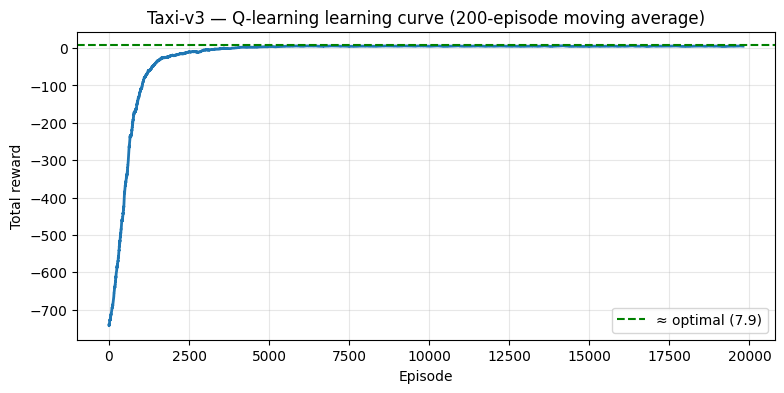

In [13]:
# ✅ PROVIDED — smoothed learning curve
def moving_average(x, w=200):
    return np.convolve(x, np.ones(w)/w, mode="valid")

plt.figure(figsize=(9, 4))
plt.plot(moving_average(rewards_per_episode), linewidth=2)
plt.axhline(7.9, color="green", ls="--", label="≈ optimal (7.9)")
plt.title("Taxi-v3 — Q-learning learning curve (200-episode moving average)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Watch the trained agent  ✅ PROVIDED

Greedy rollout (ε = 0). You should see the taxi drive to the passenger, pick up,
drive to the destination, and drop off in a small number of steps.

In [12]:
# ✅ PROVIDED — greedy evaluation
def evaluate(Q, n_eval=100, render_one=False):
    eval_env = gym.make("Taxi-v3", render_mode="ansi")
    returns, lengths = [], []
    for i in range(n_eval):
        s, _ = eval_env.reset()
        done, R, steps = False, 0, 0
        frames = []
        while not done:
            a = int(np.argmax(Q[s]))
            s, r, term, trunc, _ = eval_env.step(a)
            done = term or trunc
            R += r; steps += 1
            if render_one and i == 0:
                frames.append(eval_env.render())
        returns.append(R); lengths.append(steps)
    print(f"Average return over {n_eval} episodes: {np.mean(returns):.2f}")
    print(f"Average episode length          : {np.mean(lengths):.2f} steps")
    if render_one:
        import time
        from IPython.display import clear_output
        for f in frames:
            clear_output(wait=True); print(f); time.sleep(0.3)
    return np.mean(returns)

evaluate(Q, n_eval=100)
print("\n--- Watch one episode ---")
evaluate(Q, n_eval=1, render_one=True)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



np.float64(10.0)

## 9. Ablation experiments — build intuition  📝 TODO (written)

Re-run training (you can copy the loop into new cells) changing **one** hyperparameter
at a time. For each, paste the learning curve and answer in 2–4 sentences.

**A. Discount γ = 0.** The agent becomes myopic — it only cares about the immediate
reward. **✍️ Your prediction & result:** *(write here)*

**B. No exploration decay (ε fixed at 1.0).** The agent acts randomly forever even
while learning Q. Does the *learned greedy policy* still work? Why does the *training
reward curve* stay low even if it does? **✍️ Your answer:** *(write here)*

**C. Learning rate α = 1.0.** The update fully overwrites the old estimate every step.
On a *stochastic* env this is unstable; Taxi is deterministic, so what happens here?
**✍️ Your answer:** *(write here)*

**D. (Concept) Why does initializing Q to zeros count as mildly "optimistic" given
that every real reward is ≤ +20 but most steps give −1?** **✍️ Your answer:** *(write here)*

## 10. Stretch (optional) — SARSA vs Q-learning

Implement **SARSA**, the *on-policy* cousin. The only change is the TD target:

- Q-learning (off-policy):  `target = r + γ · max_a' Q(s', a')`
- SARSA (on-policy):        `target = r + γ · Q(s', a')`  where `a'` is the action
  actually chosen by epsilon-greedy in `s'`.

Train both and compare. (The famous payoff is on `CliffWalking-v0`, where SARSA
learns a "safer" path and Q-learning the optimal-but-riskier one — try it if you
have time.)

## ✅ Submission checklist
- [ ] All `# 📝 TODO` code cells run with no `NotImplementedError`.
- [ ] Learning curve climbs to ≈ +7–8.
- [ ] Greedy evaluation averages ≥ +7 over 100 episodes.
- [ ] Ablations A–D answered in writing.
- [ ] (Optional) SARSA comparison.

**Submit:** this notebook with all cells run (File → Download → `.ipynb`).